In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# Ler o arquivo
gdf = gpd.read_file("mun_ods.gpkg")

# Garantir que as colunas existem e são numéricas
for col in ['ODS_score', 'PIB_percapita']:
    gdf[col] = pd.to_numeric(gdf[col], errors='coerce')

# Remover registros sem dados nessas variáveis
gdf = gdf.dropna(subset=['ODS_score', 'PIB_percapita'])

# Classificar as variáveis em 3 classes (quantil)
gdf['ODS_class'] = pd.qcut(gdf['ODS_score'], q=3, labels=[1, 2, 3])
gdf['PIB_class'] = pd.qcut(gdf['PIB_percapita'], q=3, labels=[1, 2, 3])

# Criar código bivariado
gdf['bivar_code'] = gdf['ODS_class'].astype(str) + gdf['PIB_class'].astype(str)

#  Paleta bivariada
colors = {
    '11': '#e8e8e8', '12': '#ace4e4', '13': '#5ac8c8',
    '21': '#dfb0d6', '22': '#a5add3', '23': '#5698b9',
    '31': '#be64ac', '32': '#8c62aa', '33': '#3b4994'
}
gdf['color'] = gdf['bivar_code'].map(colors)

# Atribuir cor neutra aos valores ausentes
gdf['color'] = gdf['color'].fillna('#d9d9d9')  # cinza claro

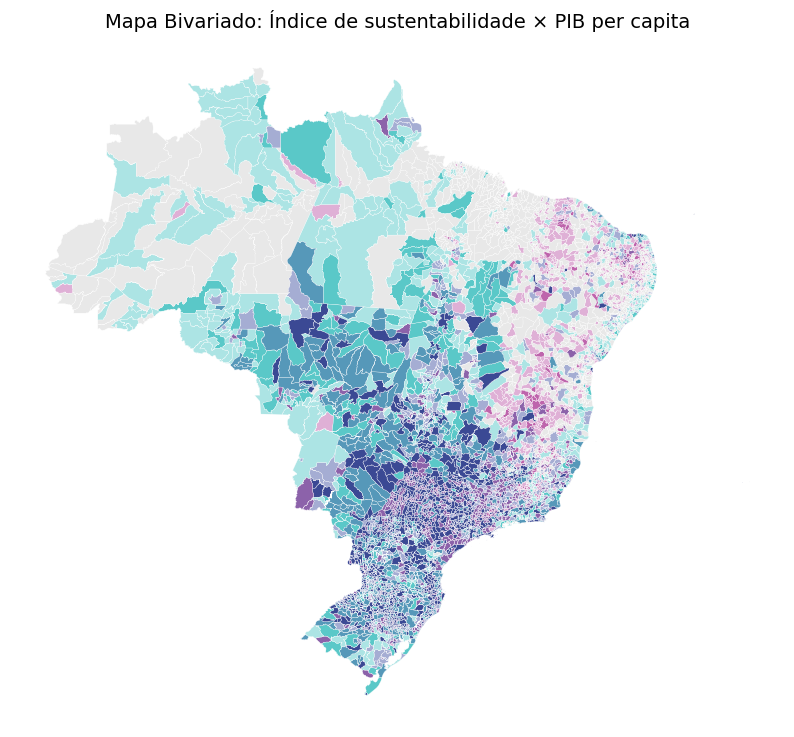

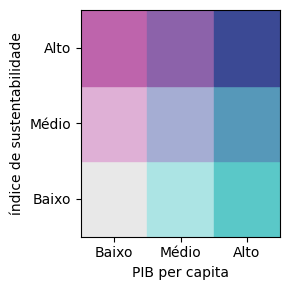

In [9]:
# Plotar o mapa
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
gdf.plot(color=gdf['color'], ax=ax, edgecolor='white', linewidth=0.2)
ax.set_title("Mapa Bivariado: Índice de sustentabilidade × PIB per capita", fontsize=14)
ax.axis('off')

# Criar legenda bivariada
legend = np.array([
    ['#e8e8e8', '#ace4e4', '#5ac8c8'],
    ['#dfb0d6', '#a5add3', '#5698b9'],
    ['#be64ac', '#8c62aa', '#3b4994']
])

fig2, ax2 = plt.subplots(figsize=(3, 3))
for i in range(3):
    for j in range(3):
        ax2.add_patch(plt.Rectangle((i, j), 1, 1, color=legend[j, i]))
ax2.set_xticks([0.5, 1.5, 2.5])
ax2.set_xticklabels(['Baixo', 'Médio', 'Alto'])
ax2.set_yticks([0.5, 1.5, 2.5])
ax2.set_yticklabels(['Baixo', 'Médio', 'Alto'])
ax2.set_xlabel('PIB per capita')
ax2.set_ylabel('índice de sustentabilidade')
ax2.set_xlim(0, 3)
ax2.set_ylim(0, 3)
plt.tight_layout()

plt.show()
